In [1]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
columns = [
    'mpg', 
    'cylinders', 
    'displacement', 
    'horsepower', 
    'weight', 
    'acceleration', 
    'model_year', 
    'origin', 
    'car_name'
]

df = pd.read_csv('auto+mpg/auto-mpg.data', sep='\s+', names=columns, header=None, na_values='?')

print("--> head: quick look at the data <--")
print(df.head())
print("\n--> describe: summary stats <--")
print(df.describe())
print("\n--> info: data types and missing value <--")
print(df.info())
print("\n--> isnull: count missing values per column <--")
print(df.isnull().sum())
print("\n")
# can drop missing rows (simple, but not good), or fill blanks with dataset average. 

--> head: quick look at the data <--
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin                   car_name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  

--> describe: summary stats <--
              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  29

In [17]:
# Drop missing rows for now --> will later fill na values with dataset average? or just drop since its a small number 
df = df.dropna()
print(df_cleaned.isnull().sum())

# Check categorical values in origin
print(df['origin'].unique())

# Encode origin
# 1 = USA, 2 = Europe, 3 = Japan
origin_mapping = {
    1: 'USA',
    2: 'Europe',
    3: 'Japan'
}

df['origin_label'] = df['origin'].map(origin_mapping)

print(df[['origin', 'origin_label']].head())

[1 3 2]
   origin origin_label
0       1          USA
1       1          USA
2       1          USA
3       1          USA
4       1          USA


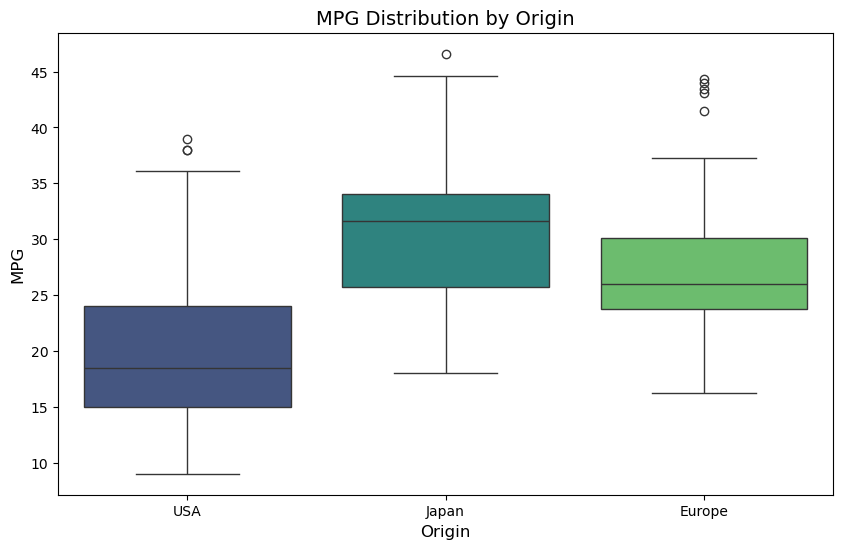

In [22]:
# Boxplot: mpg by origin
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='origin_label',
    y='mpg',
    palette='viridis',
    hue='origin_label',
    legend=False
)
plt.title('MPG Distribution by Origin', fontsize=14)
plt.xlabel('Origin', fontsize=12)
plt.ylabel('MPG', fontsize=12)
plt.show()

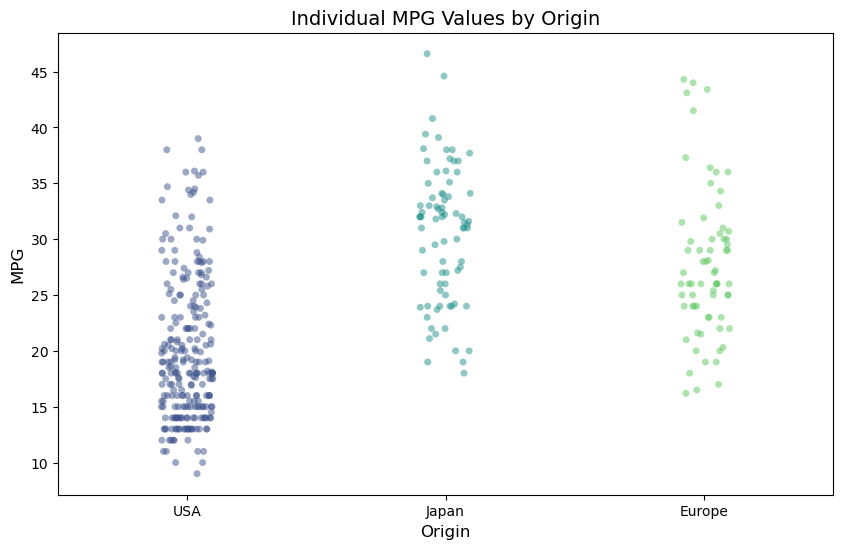

In [25]:
# Stripplot: individual mpg values by origin
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=df,
    x='origin_label',
    y='mpg',
    alpha=0.5,
    palette='viridis',
    hue='origin_label',
    legend=False,
    jitter=True
)
plt.title('Individual MPG Values by Origin', fontsize=14)
plt.xlabel('Origin', fontsize=12)
plt.ylabel('MPG', fontsize=12)
plt.show()

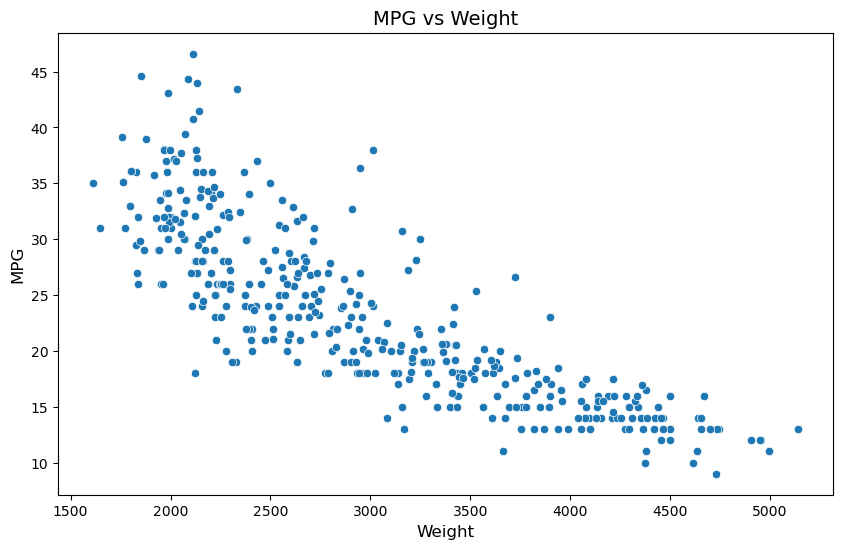

In [26]:
# Example scatterplot for a numeric feature vs target
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='weight', y='mpg')
plt.title('MPG vs Weight', fontsize=14)
plt.xlabel('Weight', fontsize=12)
plt.ylabel('MPG', fontsize=12)
plt.show()

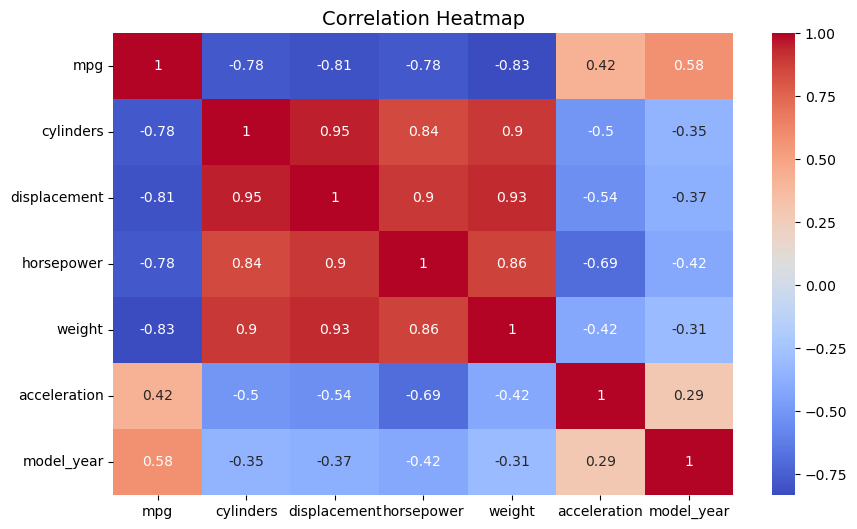

In [27]:
# Correlation heatmap for numeric features
plt.figure(figsize=(10, 6))
sns.heatmap(df[['mpg', 'cylinders', 'displacement', 'horsepower',
                'weight', 'acceleration', 'model_year']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

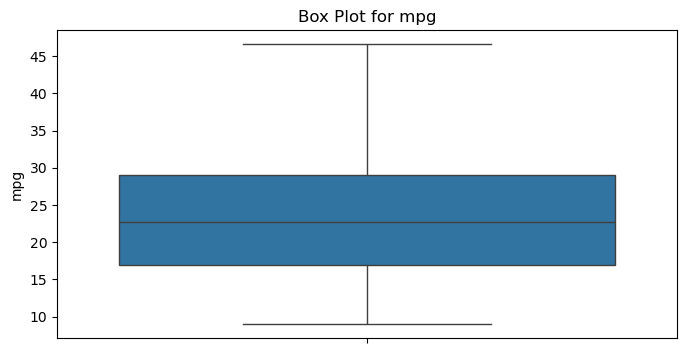

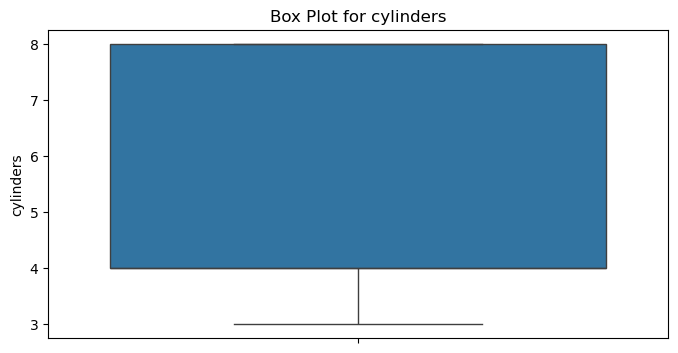

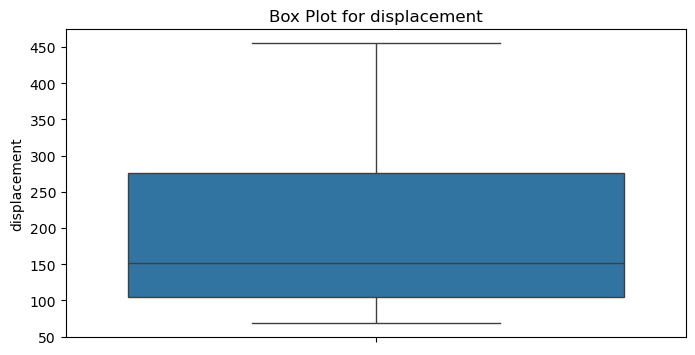

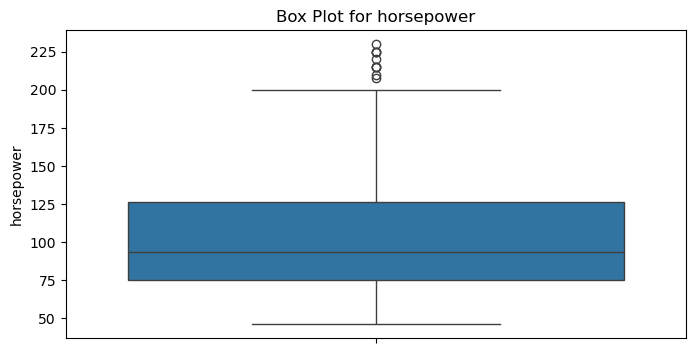

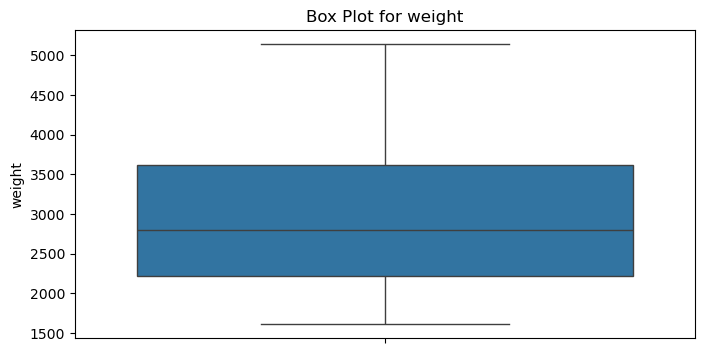

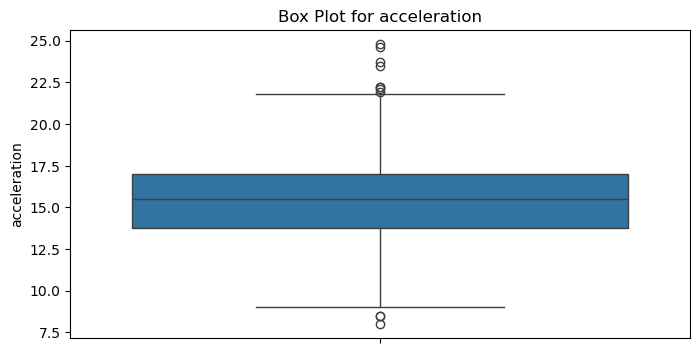

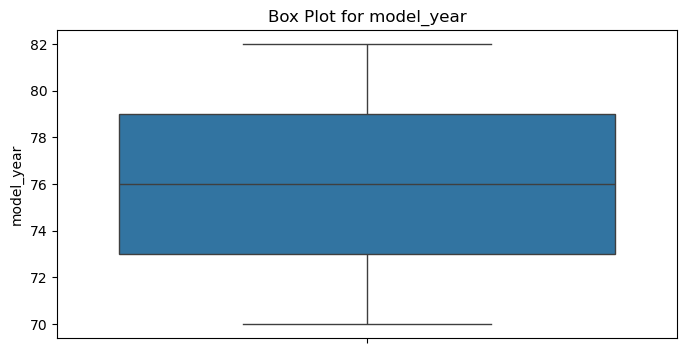

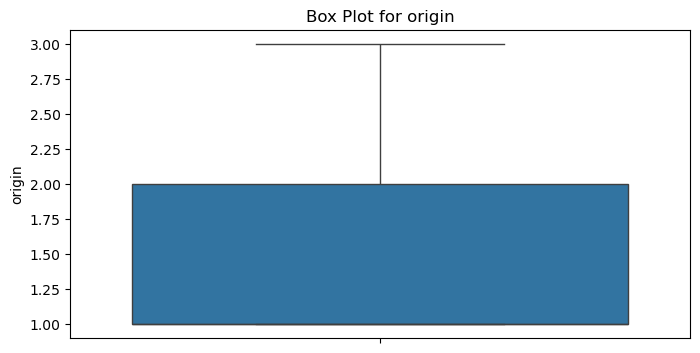

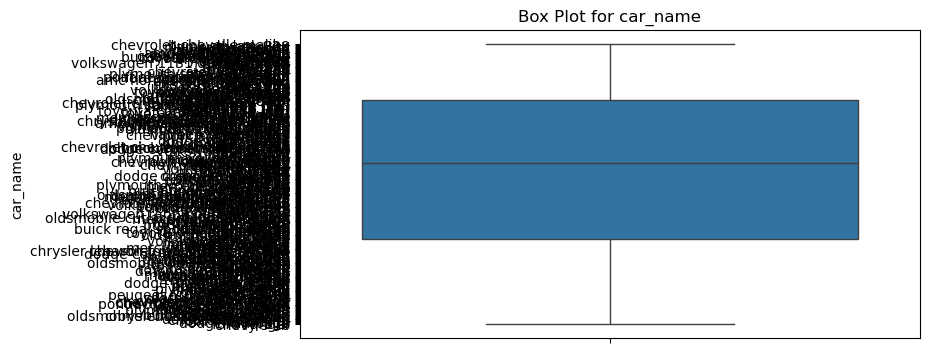

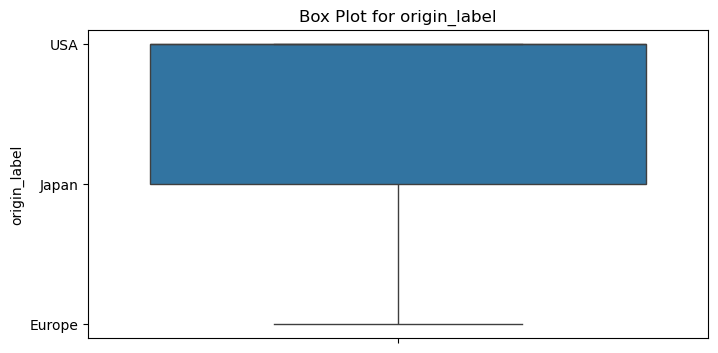

In [29]:
# Inspect for outliers
# car name boxplot looks insane- will deal with that later
for col in df.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot for {col}')
    plt.show()